In [9]:
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 14

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")
NUM_16RND = (PAYLOADSIZE-2)//2 # how many 16 bits random number included in each frame
MAX_SEQ = 256 # (decimal) maximum seq number defined by the length of the seq, the length of seq is 1B

## Log file

**For a fair comparison between groups, must follow the output format below**
<br>$\color{red}{\text{timestamp\_rx }| \text{ len [hex] } \text{ seq [hex] } \text{ payload [hex] }| \text{rssi} }$
<br>$\text{ len [hex]}$ = payload length + 1 (seq. field length [1B])
<br>$\text{ payload [hex]}$ should start with the pseudo sequence number [2B], indicates the starting byte's position in the file.
***
*Example log file output for one frame with reciever timestamp xxxx, frame length, seq number and random payload, received signal strength.*
<br>15:17:18.394 |0f 46 bd f8 f7 ea 41 ac 1b be 05 a0 7f d2 09 d4 |  -91 CRC error
<br>$\color{red}{\text{delimiter for four variables is "|" and delimiter for the payload each byte is the space " ".}}$

In [10]:
# define the file name
filename = "baseline_experiment/50cm_from_recv"
# import file to jupyter notebook
df = readfile("./" + filename + ".csv")
# check the imported data first 10 lines
df.head(10)

,index,time_rx,rssi,seq,payload
0,0,2026-04-09 17:02:13.405,-99,143,36 b4 1d ee 20 1d 1f 89 28 92 22 12 18 18
1,1,2026-04-09 17:02:13.667,-99,144,36 c0 23 72 2c 1b 1e e9 2b e9 2b b5 1d c4
2,2,2026-04-09 17:02:13.926,-98,145,36 cc 1a 4f 0b ff 14 9f 19 01 5b 04 12 6f
3,3,2026-04-09 17:02:14.178,-99,146,36 d8 21 72 22 51 2c 98 1c 58 27 07 24 cb
4,4,2026-04-09 17:02:14.444,-97,147,36 e4 24 d2 28 9a 24 88 26 22 23 5d 1a 8b
5,5,2026-04-09 17:02:14.703,-102,148,36 d0 1b 98 24 3d 2b 6e 22 21 27 7a 21 92
6,6,2026-04-09 17:02:14.963,-99,149,36 fc 15 7d 7d ff fd e5 24 18 28 7f fd c0
7,7,2026-04-09 17:02:15.224,-102,150,37 08 23 80 18 bd 1f 88 22 16 27 d6 27 26
8,8,2026-04-09 17:02:15.737,-96,152,37 20 27 b4 1e 40 13 4c 27 e3 1c 7c 22 ad
9,9,2026-04-09 17:02:16.000,-99,153,17 2c 12 11 22 bc 1a 1f 2a d5 20 91 19 1c


In [11]:
# delete packets of invalid length (aka. error in length field at variable receiver length config) (PAYLOADSIZE + 2B pesudo sequence number)
test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
test.reset_index(inplace=True)

# Time

## Definition

**Evaluation metric**
<br>*File Transmission Time: the total latency that certain amount of Data $F$ is delivered to the destination.*
<br> $File\ Delay = Rx\_timestamp[N] - Rx\_timestamp[0]$
<br> where $N$ is the last packet
***
**Interesting to look at**:
<br>*Timestamp difference*: $\Delta T[i] = Rx\_timestamp[i] - Tx\_timestamp[i]$
1. *Worst-case packet delay*: the delay of the packet that takes the longest time to traverse.
2. *Packet delay variation*: the std of the packet delay.

In [12]:
# compute the file delay
file_delay = df.time_rx[len(df) - 1] - df.time_rx[0]
# convert the timedelta to s
file_delay_s = np.timedelta64(file_delay, "ms").astype(int) / 1000
print(f"The time it takes to transfer the file is : {file_delay}, which is {file_delay_s} seconds.")

The time it takes to transfer the file is : 0 days 00:01:14.398000, which is 74.398 seconds.


# Reliability

## Definition

**Evaluation metric**
<br>*Quality of data transfer.*
<br>*Bit Reliability*: The ratio of data bits correctly delivered to the data sink.
<br>*Bit Error Rate*: The ratio of data bits incorrectly delivered to the data sink.
$$Bit\ Reliability = 1 - BER = 1 - \frac{Number\ of\ wrong\ bit}{Total\ Number\ of\ bit\ received}$$
<br>*Achieved Data Rate*: The bit error rate is calculated based on the received data only. Missing packets do not affect the bit error rate, but are reflected in the achievable data rate.

## Statistics

In [13]:
# compute the BER for all received packets
# return the in total ber for received file, error statistics and correct file content supposed to be transmitted
ber = compute_ber(test, PACKET_LEN=NUM_16RND*2)
bit_reliability = (1-ber)*100
print(f"Bit error rate [%]: {(ber*100):.8f}\t\t(in received packets within pseudo sequence + payload) ")
if len(df) < 1:
    print("Data rate [bit/s]: More than one packet required for analysis.")
else:
    print(f"Data rate [bit/s]: {(len(df)*NUM_16RND*2/file_delay_s):.8f}\t\t(directly impacted by missed packets) ")

The total number of packets transmitted by the tag is 175.
Bit error rate [%]: 7.05803571		(in received packets within pseudo sequence + payload) 
Data rate [bit/s]: 32.25893169		(directly impacted by missed packets) 


Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.


Text(0.5, 0, 'Seq. Number')

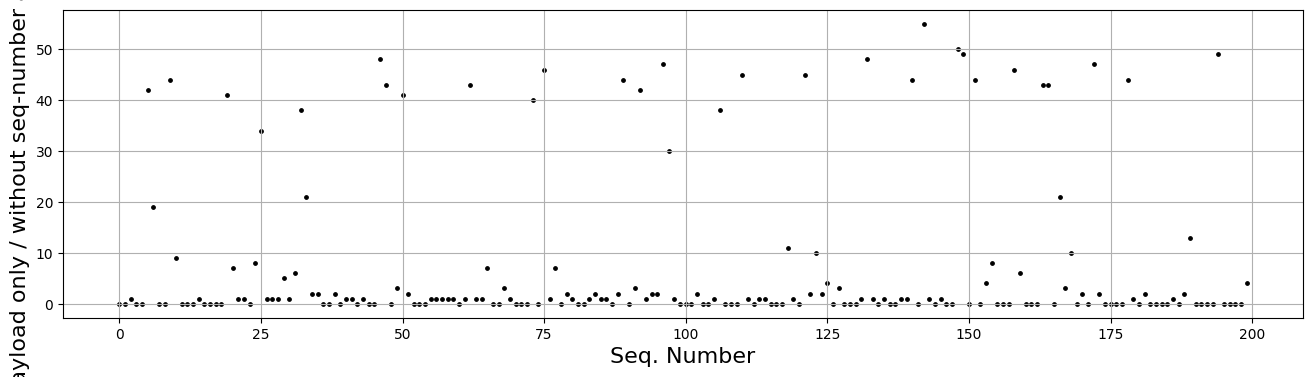

In [14]:
# BER for each packet
print("Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.")
plt.scatter(range(len(df)), [compute_ber_packet(row,PACKET_LEN=NUM_16RND*2)[0] for (_,row) in df.iterrows()], marker='o', s=6, color='black')
plt.grid()
plt.ylabel('Bit Error Rate [%] (payload only / without seq-number and pseudo-seq-number)', fontsize=16)
plt.xlabel('Seq. Number', fontsize=16)

# Distance

## Definition

**The communication distance of the system.**
<br>$D_{1}$: the distance between carrier<->backscatter_tag[m]
<br>$D_{2}$: the distance between backscatter_tag<->receiver[m]
<br> Distance metric = $D_{1}^2D_{2}^2$
<br>

In [15]:
# record the distance
dis_carrier_tag = 1
dis_tag_rx = 4

dis_metric = dis_carrier_tag**2*dis_tag_rx**2
print(f"Distance metric is: {dis_metric}")

Distance metric is: 16


# Radarplot

**Please pay attention to the unit**
<br> <font color='red'>Time</font>: use second as unit
<br> <font color='red'>Reliability</font>: use the percent as unit
<br> <font color='red'>Distance</font>: use meter as unit
<br>**Metics = [Time(s), Reliability(%), Distance(m)]**
<br> <font color='red'>Always keep the reference in your plot.</font>
<br> Tips: for ploting, time metric uses $\frac{1}{Time}*1000$ as the time metric, the higher the value the better the system performance

[np.float64(74.398), 92.94196428571428, 16]


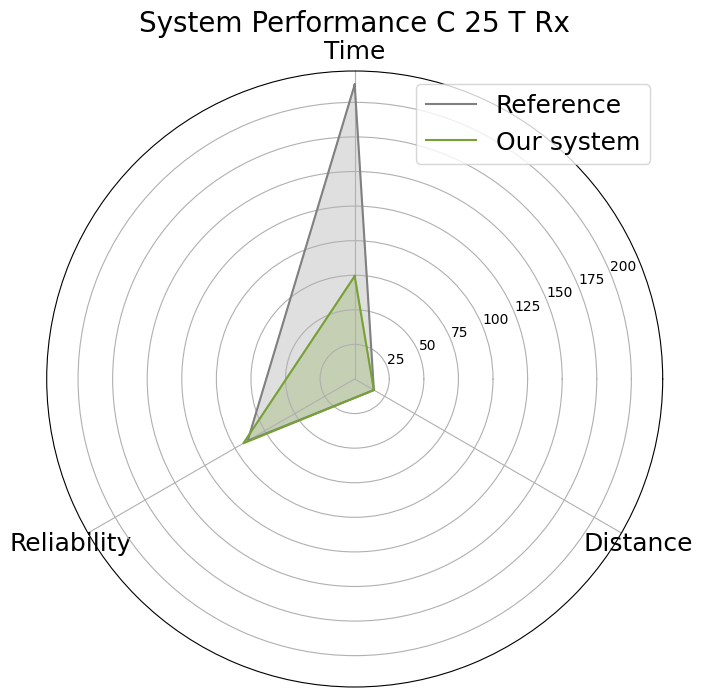

In [16]:
metrics = [file_delay_s, bit_reliability, dis_metric]

system_ref_baseline_c25 = [57.284, 96.41, 16] # C ->(25cm) Tag
system_ref_baseline_c50 = [np.float64(100.318), 92.21428571428572, 16] # C ->(50cm) Tag
system_ref_baseline_middle = [0, 0, 0] # C -> (150) Tag -> (150) Receiver
system_ref_baseline_rx50 = [np.float64(212.826), 89.36160714285715, 16] # Tag ->(50cm) Receiver
system_ref_baseline_rx25 = [np.float64(121.055), 91.36607142857143, 16] # # Tag ->(25cm) Receiver


print(metrics)
#                                                 25cm                            3m
title = "System Performance C 25 T Rx" # Carrier ------> Tag -> Receiver (Carrier --> Receiver)
radar_plot(metrics, system_ref=system_ref_baseline_rx50, title=title)